In [ ]:
import sys
print("Python:", sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading AG News...")

# Load directly from CSV - no HF issues
train_df = pd.read_csv("https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv", 
                       header=None, names=['label', 'title', 'description'])
test_df = pd.read_csv("https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv",
                      header=None, names=['label', 'title', 'description'])

# AG News labels are 1-4, convert to 0-3 for sklearn
train_df['label'] = train_df['label'] - 1
test_df['label'] = test_df['label'] - 1

# Combine title + description like HF version does
train_df['text'] = train_df['title'] + " " + train_df['description']
test_df['text'] = test_df['title'] + " " + test_df['description']

# Keep only what we need
train_df = train_df[['text','label']]
test_df = test_df[['text','label']]

print("AG News loaded")
print(f"Train size: {len(train_df)}")
print(f"Test size: {len(test_df)}")
print(f"Classes: {train_df['label'].unique()}")
train_df.head()

Python: c:\Program Files\Python311\python.exe
Loading AG News...
AG News loaded
Train size: 120000
Test size: 7600
Classes: [2 3 1 0]


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


Cell 1 — Label Mapping

In [2]:
label_map = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

print("Label Distribution:")
print(train_df["label"].map(label_map).value_counts())

Label Distribution:
label
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


Interpretation

The AG News dataset is perfectly balanced.

This is important because:

No class dominates training.
Accuracy is a meaningful metric.
No need for oversampling or undersampling.
No need for class weighting.

In your report later:

"The dataset contains four equally represented classes with 30,000 samples each, resulting in a balanced classification problem."

Cell 2 — Class Distribution Plot

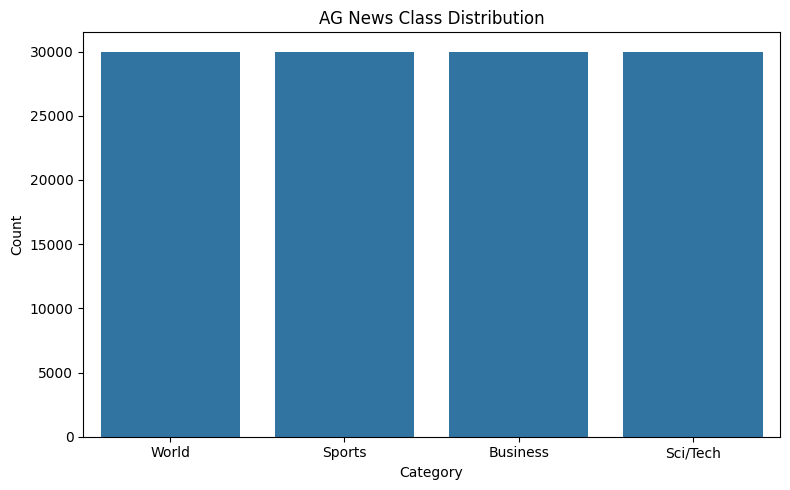

In [3]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=train_df["label"].map(label_map),
    order=["World","Sports","Business","Sci/Tech"]
)

plt.title("AG News Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Interpretation

News articles are relatively short.

This is good because:

TF-IDF works extremely well on short texts.
Training will be fast.
Memory requirements remain low.

Cell 3 — Document Length Analysis

In [4]:
train_df["text_length"] = train_df["text"].apply(lambda x: len(str(x).split()))

print(train_df["text_length"].describe())

count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64


Cell 4 — Category-wise Length

In [5]:
train_df.groupby("label")["text_length"].mean().rename(index=label_map)

label
World       38.884867
Sports      37.774733
Business    37.538233
Sci/Tech    37.191967
Name: text_length, dtype: float64

Interpretation

All categories have nearly identical lengths.

This means:

Classification performance won't be biased by document length.
The model must learn actual content rather than length differences.